In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [4]:
purchases = pd.read_csv("amazon-purchases.csv")
survey = pd.read_csv("survey2.csv")

In [5]:
purchases.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 8 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Order Date                1850717 non-null  object 
 1   Purchase Price Per Unit   1850717 non-null  float64
 2   Quantity                  1850717 non-null  float64
 3   Shipping Address State    1762905 non-null  object 
 4   Title                     1760977 non-null  object 
 5   ASIN/ISBN (Product Code)  1849744 non-null  object 
 6   Category                  1761259 non-null  object 
 7   Survey ResponseID         1850717 non-null  object 
dtypes: float64(2), object(6)
memory usage: 113.0+ MB


In [6]:
purchases_samsung = purchases[
    purchases["Title"].str.contains(r"\bsamsung\b", case=False, regex=True, na=False)
].copy()

purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19706 entries, 5 to 1850564
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order Date                19706 non-null  object 
 1   Purchase Price Per Unit   19706 non-null  float64
 2   Quantity                  19706 non-null  float64
 3   Shipping Address State    19136 non-null  object 
 4   Title                     19706 non-null  object 
 5   ASIN/ISBN (Product Code)  19704 non-null  object 
 6   Category                  19699 non-null  object 
 7   Survey ResponseID         19706 non-null  object 
dtypes: float64(2), object(6)
memory usage: 1.4+ MB


## Deteccion de duplicados de purchases_samsung

In [7]:
purchases_samsung.duplicated().sum()

25

## Eliminacion de duplicados

In [8]:
purchases_samsung.drop_duplicates(inplace=True)
purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19681 entries, 5 to 1850564
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order Date                19681 non-null  object 
 1   Purchase Price Per Unit   19681 non-null  float64
 2   Quantity                  19681 non-null  float64
 3   Shipping Address State    19114 non-null  object 
 4   Title                     19681 non-null  object 
 5   ASIN/ISBN (Product Code)  19679 non-null  object 
 6   Category                  19674 non-null  object 
 7   Survey ResponseID         19681 non-null  object 
dtypes: float64(2), object(6)
memory usage: 1.4+ MB


## Deteccion de nulos de base de datos samsung

In [9]:
purchases_samsung.isnull().sum()

Order Date                    0
Purchase Price Per Unit       0
Quantity                      0
Shipping Address State      567
Title                         0
ASIN/ISBN (Product Code)      2
Category                      7
Survey ResponseID             0
dtype: int64

Vamos a eliminar los datos nulos porque equivale a 2.9% de los datos para samsung

In [10]:
purchases_samsung=purchases_samsung.dropna()
purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19107 entries, 5 to 1850564
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order Date                19107 non-null  object 
 1   Purchase Price Per Unit   19107 non-null  float64
 2   Quantity                  19107 non-null  float64
 3   Shipping Address State    19107 non-null  object 
 4   Title                     19107 non-null  object 
 5   ASIN/ISBN (Product Code)  19107 non-null  object 
 6   Category                  19107 non-null  object 
 7   Survey ResponseID         19107 non-null  object 
dtypes: float64(2), object(6)
memory usage: 1.3+ MB


## Cambio tipo de variables

In [11]:
purchases_samsung["Order Date"]=pd.to_datetime(purchases_samsung["Order Date"], errors="coerce")
purchases_samsung.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 19107 entries, 5 to 1850564
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order Date                19107 non-null  datetime64[ns]
 1   Purchase Price Per Unit   19107 non-null  float64       
 2   Quantity                  19107 non-null  float64       
 3   Shipping Address State    19107 non-null  object        
 4   Title                     19107 non-null  object        
 5   ASIN/ISBN (Product Code)  19107 non-null  object        
 6   Category                  19107 non-null  object        
 7   Survey ResponseID         19107 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 1.3+ MB


## EDA survey

In [12]:
survey.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5027 entries, 0 to 5026
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Survey ResponseID           5027 non-null   object
 1   Q-demos-age                 5027 non-null   object
 2   Q-demos-hispanic            5027 non-null   object
 3   Q-demos-race                5027 non-null   object
 4   Q-demos-education           5027 non-null   object
 5   Q-demos-income              5027 non-null   object
 6   Q-demos-gender              5027 non-null   object
 7   Q-sexual-orientation        5027 non-null   object
 8   Q-demos-state               5027 non-null   object
 9   Q-amazon-use-howmany        5027 non-null   object
 10  Q-amazon-use-hh-size        5027 non-null   object
 11  Q-amazon-use-how-oft        5027 non-null   object
 12  Q-substance-use-cigarettes  5027 non-null   object
 13  Q-substance-use-marijuana   5027 non-null   obje

Solo el 32.6% de los encuestados quisieron compartir su experiencia de vida en la encuesta por lo que se considera que el 64% de las personas no quisieron compartir esos datos por tal motivo se elimina la columna

In [13]:
survey.drop(columns=["Q-life-changes"], inplace=True)
survey.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5027 entries, 0 to 5026
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Survey ResponseID           5027 non-null   object
 1   Q-demos-age                 5027 non-null   object
 2   Q-demos-hispanic            5027 non-null   object
 3   Q-demos-race                5027 non-null   object
 4   Q-demos-education           5027 non-null   object
 5   Q-demos-income              5027 non-null   object
 6   Q-demos-gender              5027 non-null   object
 7   Q-sexual-orientation        5027 non-null   object
 8   Q-demos-state               5027 non-null   object
 9   Q-amazon-use-howmany        5027 non-null   object
 10  Q-amazon-use-hh-size        5027 non-null   object
 11  Q-amazon-use-how-oft        5027 non-null   object
 12  Q-substance-use-cigarettes  5027 non-null   object
 13  Q-substance-use-marijuana   5027 non-null   obje

## Identificacion de duplicados

In [14]:
survey.duplicated().sum()

0

## Deteccion de atipicos

In [29]:
purchases_samsung[["Purchase Price Per Unit", "Quantity"]].describe()

,Purchase Price Per Unit,Quantity
count,19107.000000,19107.000000
mean,31.570856,1.036426
std,88.191246,0.251516
min,0.010000,1.000000
25%,8.990000,1.000000
50%,12.600000,1.000000
75%,19.990000,1.000000
max,1862.870000,10.000000


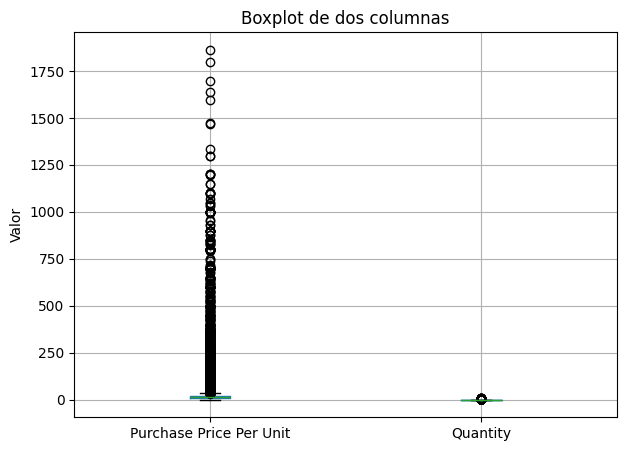

In [30]:

cols = ["Purchase Price Per Unit", "Quantity"]

purchases_samsung[cols].boxplot(figsize=(7, 5))
plt.title("Boxplot de dos columnas")
plt.ylabel("Valor")
plt.show()

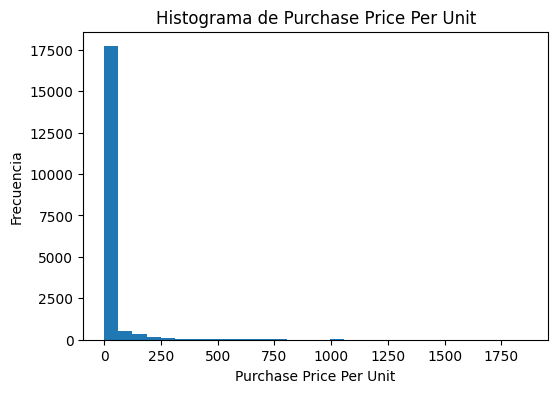

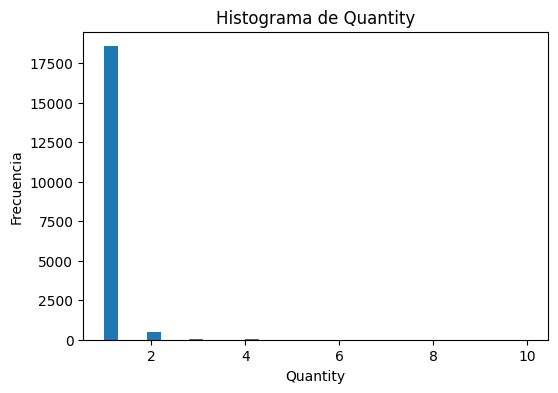

In [31]:
cols = ["Purchase Price Per Unit", "Quantity"]

for col in cols:
    plt.figure(figsize=(6, 4))
    plt.hist(purchases_samsung[col].dropna(), bins=30)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

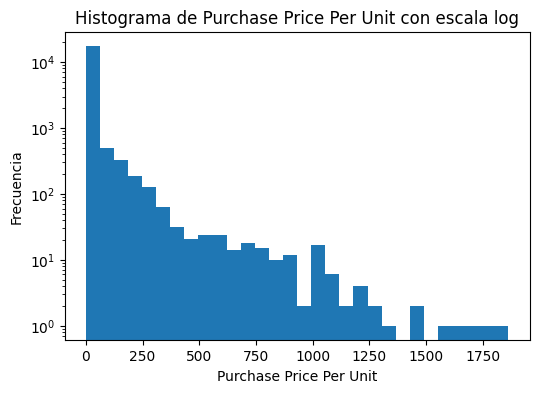

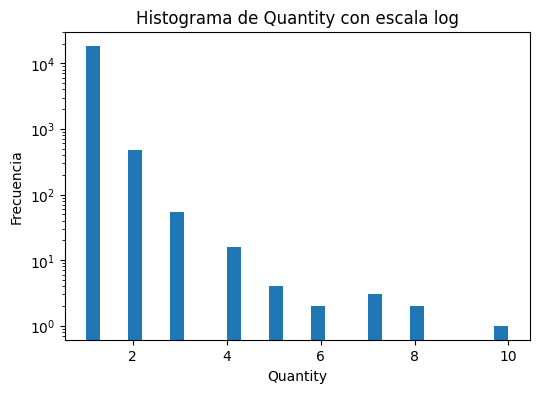

In [32]:
for col in ["Purchase Price Per Unit", "Quantity"]:
    plt.figure(figsize=(6, 4))
    plt.hist(purchases_samsung[col].dropna(), bins=30)
    plt.yscale("log")
    plt.title(f"Histograma de {col} con escala log")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

## Comentario sobre segmentacion de clientes
- Para que la segmentación tenga utilidad práctica, usted debe poder cruzar los grupos hallados con los resultados del modelo de billetera (SoW y SioW). Si los IDs en su agrupación no coinciden exactamente con los de las matrices V y W del modelo original, la comparación pierde todo sentido estadístico porque estaría analizando poblaciones distintas.  
- El diseño experimental utiliza dos horizontes temporales no traslapados: T1 (ventana de características, 2018-2021) y T2 (ventana de respuesta/evaluación, 2021-2023).
- T2 se reserva exclusivamente para validar cómo se comportaron esos grupos en el futuro. Agrupar usando datos de T2 para caracterizar segmentos de T1 causaría un error de anacronismo o fuga de información (data leakage), invalidando cualquier conclusión sobre la capacidad del modelo para identificar perfiles de consumo antes de que ocurra la compra.

## Base de datos para k means

In [ ]:
# Se crea columna amount como gasto total para crear el rfm
purchases_samsung["amount"] = purchases_samsung["Purchase Price Per Unit"] * purchases_samsung["Quantity"]

<class 'pandas.core.frame.DataFrame'>
Index: 19107 entries, 5 to 1850564
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order Date                19107 non-null  datetime64[ns]
 1   Purchase Price Per Unit   19107 non-null  float64       
 2   Quantity                  19107 non-null  float64       
 3   Shipping Address State    19107 non-null  object        
 4   Title                     19107 non-null  object        
 5   ASIN/ISBN (Product Code)  19107 non-null  object        
 6   Category                  19107 non-null  object        
 7   Survey ResponseID         19107 non-null  object        
 8   amount                    19107 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 1.5+ MB


In [18]:
# Filtrar primero la ventana T1
T1_START = pd.to_datetime("2018-01-01")
T1_END   = pd.to_datetime("2021-10-31")

purchases_T1 = purchases_samsung[
    (purchases_samsung["Order Date"] >= T1_START) &
    (purchases_samsung["Order Date"] <= T1_END) &
    (purchases_samsung["amount"] > 0)
].copy()

purchases_T1.shape

(13285, 9)

In [ ]:
base_kmeans = (
    purchases_T1
    .groupby("Survey ResponseID")
    .agg(
        recency_days=("Order Date", lambda x: (T1_END - x.max()).days),
        frequency=("Order Date", "count"),
        monetary=("amount", "sum"),
        avg_ticket=("amount", "mean"),
        total_units=("Quantity", "sum"),
        n_categories=("Category", "nunique"),
        n_products=("Title", "nunique")
    )
    .reset_index()
)

base_kmeans.head()

,Survey ResponseID,recency_days,frequency,monetary,avg_ticket,total_units,n_categories,n_products
0,R_01vNIayewjIIKMF,248,9,270.91,30.101111,9.0,4,5
1,R_037XK72IZBJyF69,146,5,57.45,11.490000,5.0,3,5
2,R_03aEbghUILs9NxD,23,1,10.99,10.990000,1.0,1,1
3,R_06RZP9pS7kONINr,159,2,63.94,31.970000,2.0,2,2
4,R_06d9ULxrBmkwSTn,215,7,159.46,22.780000,7.0,6,7


In [23]:
base_kmeans.shape

(3067, 8)

## Comentario paso train_ids

Los train_ids sirven para quedarte solamente con los clientes que pertenecen al conjunto de entrenamiento.
La exportación de estos IDs permite reutilizar exactamente la misma partición train/test en otros análisis posteriores, como la segmentación de clientes.
Esto es importante porque garantiza comparabilidad metodológica entre el modelo
Pogit y los modelos de agrupamiento: los clústeres se construyen usando solo
clientes de entrenamiento y luego pueden evaluarse sobre clientes de testeo,
respetando la misma división de datos y evitando fuga de información.

In [25]:
train_ids = pd.read_csv("train_ids.csv")["response_id"].astype(str)

base_train = base_kmeans[
    base_kmeans["Survey ResponseID"].isin(train_ids)
].copy()
print(base_train.shape)
base_train.head()


(1846, 8)


,Survey ResponseID,recency_days,frequency,monetary,avg_ticket,total_units,n_categories,n_products
0,R_01vNIayewjIIKMF,248,9,270.91,30.101111,9.0,4,5
1,R_037XK72IZBJyF69,146,5,57.45,11.490000,5.0,3,5
2,R_03aEbghUILs9NxD,23,1,10.99,10.990000,1.0,1,1
4,R_06d9ULxrBmkwSTn,215,7,159.46,22.780000,7.0,6,7
5,R_08uYA7fb4unHGkF,48,1,293.00,293.000000,1.0,1,1


## k -means

### Analisis de correlacion

In [26]:
cols_kmeans = [
    "recency_days",
    "frequency",
    "monetary",
    "avg_ticket",
    "total_units",
    "n_categories",
    "n_products"
]

corr = base_kmeans[cols_kmeans].corr(method="spearman")
corr

,recency_days,frequency,monetary,avg_ticket,total_units,n_categories,n_products
recency_days,1.000000,-0.489962,-0.364385,-0.079126,-0.483493,-0.469462,-0.490265
frequency,-0.489962,1.000000,0.786064,0.218391,0.993743,0.934324,0.989764
monetary,-0.364385,0.786064,1.000000,0.732977,0.787416,0.774609,0.782479
avg_ticket,-0.079126,0.218391,0.732977,1.000000,0.230863,0.277642,0.222641
total_units,-0.483493,0.993743,0.787416,0.230863,1.000000,0.928740,0.982950
n_categories,-0.469462,0.934324,0.774609,0.277642,0.928740,1.000000,0.945467
n_products,-0.490265,0.989764,0.782479,0.222641,0.982950,0.945467,1.000000


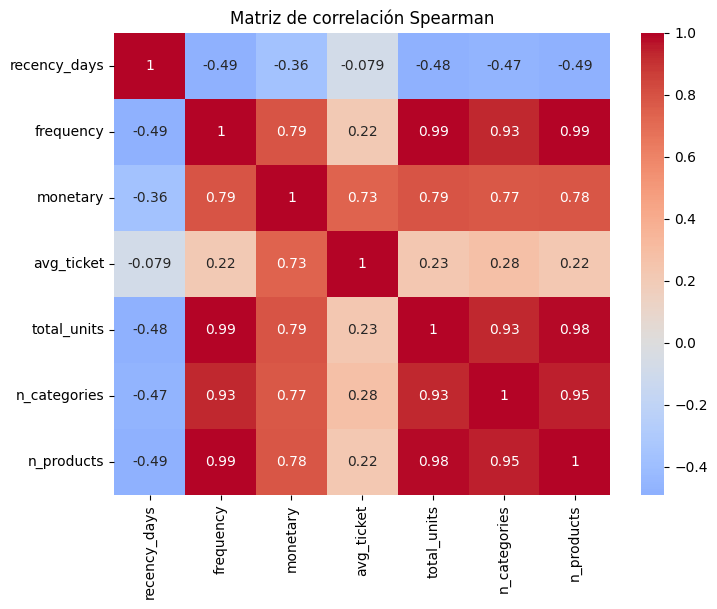

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación Spearman")
plt.show()

In [ ]:
X = base_train[["recency_days", "frequency", "monetary"]]
#pipeline kmeans
pipeline_kmeans = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=7, random_state=42, n_init=20))
])

pipeline_kmeans.fit(X)
labels_kmeans = pipeline_kmeans.named_steps["kmeans"].labels_